# Chapter 12: DPO and GRPO — Alignment Without PPO

*Build a Multimodal Model from Scratch · Chapter 12*

> **This chapter in context:** Ch11 trained a reward model that scores (image, caption) pairs. The natural next step is to use that score to improve the VLM — but PPO (the classic RL algorithm for this) is notoriously unstable and requires 4 models running simultaneously. This chapter shows two simpler alternatives: DPO (no RL loop, no reward model) and GRPO (no reward model, just a verifier). Together these cover the full modern alignment toolkit.

In [1]:
%matplotlib inline
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, copy
from torch.utils.data import Dataset, DataLoader
import math
torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PAL = dict(bg='#F8F9FA', dark='#2C3E50', blue='#4A90D9', orange='#E67E22',
           green='#27AE60', red='#E74C3C', purple='#8E44AD', grey='#95A5A6')
VOCAB = ["<pad>","<bos>","<eos>","a","red","blue","green","yellow",
         "circle","square","triangle","star","correct","wrong","good","bad"]
w2i = {w:i for i,w in enumerate(VOCAB)}; i2w = {i:w for i,w in enumerate(VOCAB)}
CAPTIONS = [["<bos>","a","red","circle","<eos>"],["<bos>","a","blue","square","<eos>"],
            ["<bos>","a","green","triangle","<eos>"],["<bos>","a","yellow","star","<eos>"]]
print(f"Device: {DEVICE}")

Device: cpu


## Problem 1 — Why Not Just Use PPO?

Before DPO and GRPO, the standard alignment recipe was **RLHF with PPO**. Here is why that is painful:

**The PPO pipeline for RLHF requires 4 models in memory simultaneously:**
1. **Reference policy** (frozen SFT copy) — computes KL baseline
2. **Policy** (trainable) — the model being aligned
3. **Value model** — estimates expected future reward (a separate network)
4. **Reward model** — scores each completion

**Why PPO is unstable:**
- The RL training loop has its own inner optimisation loop (the "trust-region" update)
- KL budget, clipping coefficient, value loss weight — all need careful tuning
- Reward hacking is common: the policy finds ways to maximise reward that are not aligned with human intent
- Gradient variance from the RL objective is much higher than supervised loss

**Complexity:** The PPO training loop is 3× more code than SFT, requires synchronised rollout generation and value estimation, and typically needs 8× the VRAM of SFT.

The diagram below compares the three pipelines covered in this chapter.

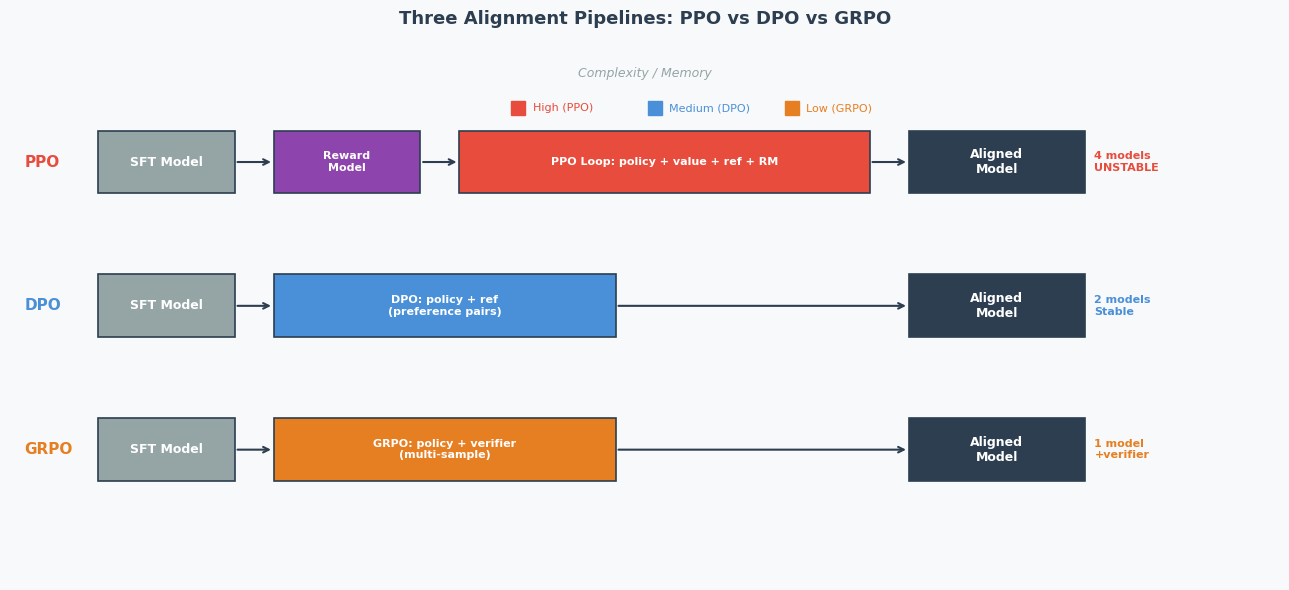

In [2]:
def draw_comparison_diagram():
    fig, ax = plt.subplots(figsize=(13, 6))
    fig.patch.set_facecolor(PAL['bg'])
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 13); ax.set_ylim(0, 6)
    ax.axis('off')

    def box(x, y, w, h, color, text, fontsize=9, text_color='white'):
        rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor=PAL['dark'],
                              linewidth=1.2, zorder=2)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center',
                fontsize=fontsize, color=text_color, fontweight='bold', zorder=3,
                wrap=True)

    def arrow(x1, y1, x2, y2, color=PAL['dark']):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5), zorder=3)

    # ---- Row 1: PPO ----
    ax.text(0.15, 4.65, 'PPO', fontsize=11, fontweight='bold', color=PAL['red'], va='center')
    box(0.9, 4.3, 1.4, 0.7, PAL['grey'], 'SFT Model', 9)
    arrow(2.3, 4.65, 2.7, 4.65)
    box(2.7, 4.3, 1.5, 0.7, PAL['purple'], 'Reward\nModel', 8)
    arrow(4.2, 4.65, 4.6, 4.65)
    box(4.6, 4.3, 4.2, 0.7, PAL['red'], 'PPO Loop: policy + value + ref + RM', 8)
    arrow(8.8, 4.65, 9.2, 4.65)
    box(9.2, 4.3, 1.8, 0.7, PAL['dark'], 'Aligned\nModel', 9)
    ax.text(11.1, 4.65, '4 models\nUNSTABLE', fontsize=8, color=PAL['red'],
            va='center', fontweight='bold')

    # ---- Row 2: DPO ----
    ax.text(0.15, 3.05, 'DPO', fontsize=11, fontweight='bold', color=PAL['blue'], va='center')
    box(0.9, 2.7, 1.4, 0.7, PAL['grey'], 'SFT Model', 9)
    arrow(2.3, 3.05, 2.7, 3.05)
    box(2.7, 2.7, 3.5, 0.7, PAL['blue'], 'DPO: policy + ref\n(preference pairs)', 8)
    arrow(6.2, 3.05, 9.2, 3.05)
    box(9.2, 2.7, 1.8, 0.7, PAL['dark'], 'Aligned\nModel', 9)
    ax.text(11.1, 3.05, '2 models\nStable', fontsize=8, color=PAL['blue'],
            va='center', fontweight='bold')

    # ---- Row 3: GRPO ----
    ax.text(0.15, 1.45, 'GRPO', fontsize=11, fontweight='bold', color=PAL['orange'], va='center')
    box(0.9, 1.1, 1.4, 0.7, PAL['grey'], 'SFT Model', 9)
    arrow(2.3, 1.45, 2.7, 1.45)
    box(2.7, 1.1, 3.5, 0.7, PAL['orange'], 'GRPO: policy + verifier\n(multi-sample)', 8)
    arrow(6.2, 1.45, 9.2, 1.45)
    box(9.2, 1.1, 1.8, 0.7, PAL['dark'], 'Aligned\nModel', 9)
    ax.text(11.1, 1.45, '1 model\n+verifier', fontsize=8, color=PAL['orange'],
            va='center', fontweight='bold')

    # Complexity indicator legend
    ax.text(6.5, 5.6, 'Complexity / Memory', fontsize=9, color=PAL['grey'],
            ha='center', style='italic')
    for i, (label, color) in enumerate([('High (PPO)', PAL['red']),
                                         ('Medium (DPO)', PAL['blue']),
                                         ('Low (GRPO)', PAL['orange'])]):
        ax.plot([5.2 + i*1.4], [5.25], 's', color=color, ms=10)
        ax.text(5.35 + i*1.4, 5.25, label, fontsize=8, color=color, va='center')

    ax.set_title('Three Alignment Pipelines: PPO vs DPO vs GRPO',
                 fontsize=13, fontweight='bold', color=PAL['dark'], pad=12)
    plt.tight_layout()
    plt.show()

draw_comparison_diagram()

In [3]:
def make_image(cls, size=32, noise=0.05):
    img = np.zeros((size, size, 3), dtype=np.float32)
    colors = [(1,0,0),(0,0,1),(0,0.7,0),(1,0.8,0)]
    c = colors[cls]; h,w,r = size//2,size//2,size//4
    if cls == 0:
        for i in range(size):
            for j in range(size):
                if (i-h)**2+(j-w)**2<r**2: img[i,j]=c
    elif cls == 1: img[h-r:h+r, w-r:w+r] = c
    elif cls == 2:
        for i in range(h-r,h+r):
            wid=int((i-(h-r))/(2*r)*2*r); img[i,w-wid:w+wid]=c
    else:
        for i in range(size):
            for j in range(size):
                if abs(i-h)+abs(j-w)<r: img[i,j]=c
    img += (np.random.randn(*img.shape)*noise).astype(np.float32)
    return np.clip(img,0,1)

class PatchEmbed(nn.Module):
    def __init__(self, patch_size=4, in_ch=3, embed_dim=48):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, embed_dim, patch_size, patch_size)
    def forward(self, x): return self.proj(x).flatten(2).transpose(1,2)

class MiniVLM(nn.Module):
    """Tiny VLM: ViT image encoder + GPT text decoder."""
    def __init__(self, vocab_size=16, embed_dim=48, n_heads=3, n_layers=2):
        super().__init__()
        self.n_patches = (32//4)**2  # 64
        self.patch_embed = PatchEmbed(embed_dim=embed_dim)
        self.img_pos = nn.Parameter(torch.zeros(1, self.n_patches, embed_dim))
        enc_layer = nn.TransformerEncoderLayer(embed_dim, n_heads,
                        dim_feedforward=embed_dim*4, batch_first=True, dropout=0.0)
        self.img_encoder = nn.TransformerEncoder(enc_layer, n_layers)
        self.tok_emb = nn.Embedding(vocab_size, embed_dim)
        self.txt_pos = nn.Embedding(32, embed_dim)
        dec_layer = nn.TransformerDecoderLayer(embed_dim, n_heads,
                        dim_feedforward=embed_dim*4, batch_first=True, dropout=0.0)
        self.decoder = nn.TransformerDecoder(dec_layer, n_layers)
        self.head = nn.Linear(embed_dim, vocab_size)
        nn.init.trunc_normal_(self.img_pos, std=0.02)
    def encode_image(self, img):
        x = self.patch_embed(img) + self.img_pos
        return self.img_encoder(x)  # (B, n_patches, embed_dim)
    def forward(self, img, tgt):
        memory = self.encode_image(img)
        T = tgt.size(1)
        pos = torch.arange(T, device=tgt.device).unsqueeze(0)
        x = self.tok_emb(tgt) + self.txt_pos(pos)
        mask = nn.Transformer.generate_square_subsequent_mask(T, device=tgt.device)
        x = self.decoder(x, memory, tgt_mask=mask)
        return self.head(x)  # (B, T, vocab_size)

n_params = sum(p.numel() for p in MiniVLM().parameters())
print(f"MiniVLM defined — {n_params:,} parameters")

/tmp/ipykernel_2099/1928339734.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.img_encoder = nn.TransformerEncoder(enc_layer, n_layers)


MiniVLM defined — 140,608 parameters


In [4]:
# Dataset: 40 images per class, each with correct caption
class CaptionDataset(Dataset):
    def __init__(self, n_per_class=40):
        self.samples = []
        for cls in range(4):
            for _ in range(n_per_class):
                img = torch.from_numpy(make_image(cls)).permute(2,0,1)
                cap = [w2i[t] for t in CAPTIONS[cls]]
                self.samples.append((img, torch.tensor(cap)))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

sft_data = CaptionDataset(n_per_class=40)
sft_loader = DataLoader(sft_data, batch_size=16, shuffle=True)

sft_model = MiniVLM().to(DEVICE)
opt_sft = torch.optim.Adam(sft_model.parameters(), lr=3e-3)

sft_losses = []
for epoch in range(20):
    total = 0
    for imgs, caps in sft_loader:
        imgs, caps = imgs.to(DEVICE), caps.to(DEVICE)
        logits = sft_model(imgs, caps[:,:-1])
        loss = F.cross_entropy(logits.reshape(-1,16), caps[:,1:].reshape(-1),
                                ignore_index=w2i["<pad>"])
        opt_sft.zero_grad(); loss.backward(); opt_sft.step()
        total += loss.item()
    sft_losses.append(total/len(sft_loader))

print(f"SFT final loss: {sft_losses[-1]:.4f}")

@torch.no_grad()
def evaluate_accuracy(model, n_samples=40):
    model.eval()
    correct = 0
    for cls in range(4):
        for _ in range(n_samples//4):
            img = torch.from_numpy(make_image(cls)).permute(2,0,1).unsqueeze(0).to(DEVICE)
            tgt = torch.tensor([[w2i["<bos>"]]]).to(DEVICE)
            for _ in range(4):
                logits = model(img, tgt)
                next_tok = logits[:,-1].argmax(-1, keepdim=True)
                tgt = torch.cat([tgt, next_tok], dim=1)
            gen = [i2w[t] for t in tgt[0].tolist()[1:]]
            expected_color = CAPTIONS[cls][2]
            expected_shape = CAPTIONS[cls][3]
            if expected_color in gen and expected_shape in gen:
                correct += 1
    return correct / n_samples

sft_acc = evaluate_accuracy(sft_model, n_samples=40)
print(f"SFT caption accuracy: {sft_acc*100:.1f}%")

/tmp/ipykernel_2099/1928339734.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.img_encoder = nn.TransformerEncoder(enc_layer, n_layers)


SFT final loss: 0.0025


SFT caption accuracy: 100.0%


## Part I: DPO

**Direct Preference Optimization** is a remarkable simplification: it recasts the RL alignment problem as a *supervised* binary classification over preference pairs. No RL loop, no value model, no separate reward model.

The key ingredients:
- A frozen **reference model** (our SFT model above)
- A set of **preference pairs**: for each input x, a preferred response y_w and a rejected response y_l
- A **contrastive loss** that pushes the policy to assign relatively higher probability to y_w than the reference does, and relatively lower probability to y_l

The loss has a single hyperparameter β (KL strength), is fully differentiable, and converges in the same number of steps as SFT.

## Problem 2 — The DPO Loss Derivation (Intuition)

**Step 1 — The PPO objective with KL penalty:**

The standard RLHF objective maximises reward while staying close to the reference policy:

$$\max_\pi \; \mathbb{E}[r(x, y)] - \beta \cdot \text{KL}(\pi \| \pi_{\text{ref}})$$

**Step 2 — The optimal policy has a closed form:**

Solving this constrained optimisation analytically gives:

$$\pi^*(y|x) \propto \pi_{\text{ref}}(y|x) \cdot \exp\!\left(\frac{r(x,y)}{\beta}\right)$$

**Step 3 — Invert to express reward in terms of policies:**

Taking the log and rearranging:

$$r(x, y) = \beta \cdot \log \frac{\pi^*(y|x)}{\pi_{\text{ref}}(y|x)} + Z(x)$$

where $Z(x)$ is a partition function that depends only on $x$ (not $y$).

**Step 4 — Substitute into the Bradley-Terry preference model:**

The probability that $y_w$ is preferred over $y_l$:

$$p(y_w \succ y_l) = \sigma(r(x,y_w) - r(x,y_l))$$

When we plug in the reward formula, $Z(x)$ cancels:

$$\boxed{L_{\text{DPO}} = -\log \sigma\!\Big(\beta \cdot \big[\log \tfrac{\pi_\theta(y_w|x)}{\pi_{\text{ref}}(y_w|x)} - \log \tfrac{\pi_\theta(y_l|x)}{\pi_{\text{ref}}(y_l|x)}\big]\Big)}$$

**Plain English:** "Increase the probability of the preferred response *relative to the reference*, and decrease the probability of the rejected response *relative to the reference*." No reward model needed — the reward is **implicitly defined** by the ratio of policies.

The diagram below shows what DPO does to the log-probability bars.

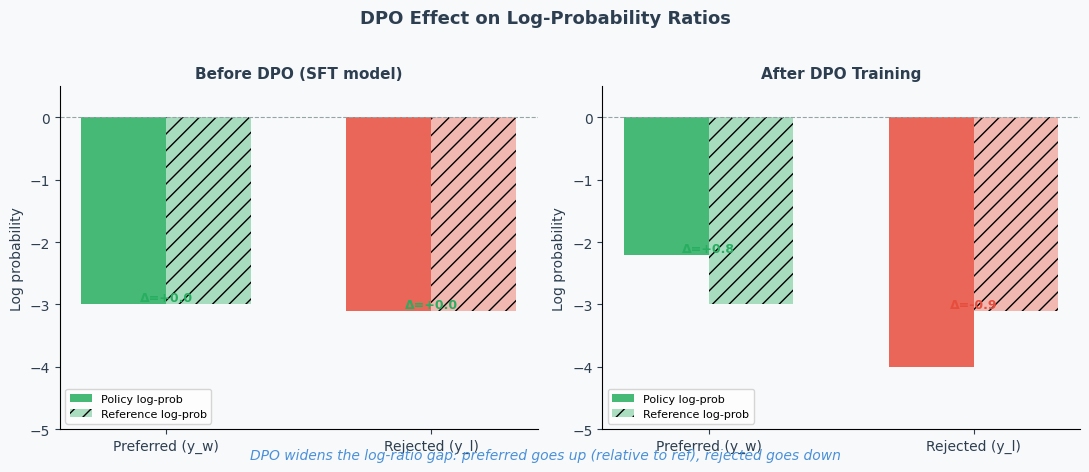

In [5]:
def draw_dpo_intuition():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.patch.set_facecolor(PAL['bg'])

    for ax, title, pol_w, pol_l, ref_w, ref_l in [
        (axes[0], 'Before DPO (SFT model)',  -3.0, -3.1, -3.0, -3.1),
        (axes[1], 'After DPO Training',      -2.2, -4.0, -3.0, -3.1),
    ]:
        ax.set_facecolor(PAL['bg'])
        x = np.arange(2)
        width = 0.32
        bars_pol = ax.bar(x - width/2, [pol_w, pol_l], width,
                          color=[PAL['green'], PAL['red']], alpha=0.85, label='Policy log-prob')
        bars_ref = ax.bar(x + width/2, [ref_w, ref_l], width,
                          color=[PAL['green'], PAL['red']], alpha=0.38, label='Reference log-prob',
                          hatch='//')

        # Ratio annotations
        for i, (pv, rv) in enumerate([(pol_w, ref_w), (pol_l, ref_l)]):
            ratio = pv - rv
            color = PAL['green'] if ratio >= 0 else PAL['red']
            ax.annotate(f'Δ={ratio:+.1f}', xy=(x[i], max(pv, rv) + 0.05),
                        ha='center', fontsize=9, color=color, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(['Preferred (y_w)', 'Rejected (y_l)'], fontsize=10, color=PAL['dark'])
        ax.set_ylabel('Log probability', fontsize=10, color=PAL['dark'])
        ax.set_title(title, fontsize=11, fontweight='bold', color=PAL['dark'])
        ax.set_ylim(-5, 0.5)
        ax.axhline(0, color=PAL['grey'], lw=0.8, linestyle='--')
        ax.legend(fontsize=8)
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(colors=PAL['dark'])

    # Arrow indicating DPO effect
    fig.text(0.5, 0.02,
             'DPO widens the log-ratio gap: preferred goes up (relative to ref), rejected goes down',
             ha='center', fontsize=10, color=PAL['blue'], style='italic')
    plt.suptitle('DPO Effect on Log-Probability Ratios', fontsize=13,
                 fontweight='bold', color=PAL['dark'], y=1.02)
    plt.tight_layout()
    plt.show()

draw_dpo_intuition()

In [6]:
def compute_log_prob(model, img, text_ids):
    """Compute sum of log probs for text_ids under model given img."""
    was_training = model.training
    model.eval()
    logits = model(img, text_ids[:,:-1])  # (B, T-1, vocab)
    log_probs = F.log_softmax(logits, dim=-1)
    target = text_ids[:,1:]  # (B, T-1)
    token_log_probs = log_probs.gather(2, target.unsqueeze(2)).squeeze(2)
    mask = (target != w2i["<pad>"]).float()
    result = (token_log_probs * mask).sum(dim=1)  # (B,)
    if was_training:
        model.train()
    return result

def dpo_loss(policy, ref_model, img, y_w, y_l, beta=0.1):
    policy.train()
    with torch.no_grad():
        ref_lp_w = compute_log_prob(ref_model, img, y_w)
        ref_lp_l = compute_log_prob(ref_model, img, y_l)
    pol_lp_w = compute_log_prob(policy, img, y_w)
    pol_lp_l = compute_log_prob(policy, img, y_l)
    ratio_w = pol_lp_w - ref_lp_w
    ratio_l = pol_lp_l - ref_lp_l
    return -F.logsigmoid(beta * (ratio_w - ratio_l)).mean(), ratio_w.mean().item(), ratio_l.mean().item()

# Create DPO dataset: preference pairs (preferred = correct, rejected = wrong class)
class DPODataset(Dataset):
    def __init__(self, n_per_class=40):
        self.samples = []
        for cls in range(4):
            for _ in range(n_per_class):
                img = torch.from_numpy(make_image(cls)).permute(2,0,1)
                y_w = [w2i[t] for t in CAPTIONS[cls]]
                rej_cls = (cls + 1 + np.random.randint(3)) % 4
                y_l = [w2i[t] for t in CAPTIONS[rej_cls]]
                self.samples.append((img, torch.tensor(y_w), torch.tensor(y_l)))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

dpo_data = DPODataset(n_per_class=40)
dpo_loader = DataLoader(dpo_data, batch_size=16, shuffle=True)
print(f"DPO dataset: {len(dpo_data)} preference pairs")
print("Example pair:")
img_ex, yw_ex, yl_ex = dpo_data[0]
print(f"  y_w (preferred): {[i2w[t.item()] for t in yw_ex]}")
print(f"  y_l (rejected):  {[i2w[t.item()] for t in yl_ex]}")

DPO dataset: 160 preference pairs
Example pair:
  y_w (preferred): ['<bos>', 'a', 'red', 'circle', '<eos>']
  y_l (rejected):  ['<bos>', 'a', 'yellow', 'star', '<eos>']


In [7]:
# Start from SFT model
dpo_model = copy.deepcopy(sft_model)
ref_model = copy.deepcopy(sft_model)
for p in ref_model.parameters(): p.requires_grad_(False)  # freeze reference

opt_dpo = torch.optim.Adam(dpo_model.parameters(), lr=5e-4)
dpo_losses, ratio_w_hist, ratio_l_hist = [], [], []

for epoch in range(20):
    total_loss, total_rw, total_rl = 0, 0, 0
    for imgs, y_w, y_l in dpo_loader:
        imgs, y_w, y_l = imgs.to(DEVICE), y_w.to(DEVICE), y_l.to(DEVICE)
        loss, rw, rl = dpo_loss(dpo_model, ref_model, imgs, y_w, y_l, beta=0.1)
        opt_dpo.zero_grad(); loss.backward(); opt_dpo.step()
        total_loss += loss.item(); total_rw += rw; total_rl += rl
    dpo_losses.append(total_loss/len(dpo_loader))
    ratio_w_hist.append(total_rw/len(dpo_loader))
    ratio_l_hist.append(total_rl/len(dpo_loader))
    if epoch % 5 == 4:
        print(f"Epoch {epoch+1}: loss={dpo_losses[-1]:.4f}  ratio_w={ratio_w_hist[-1]:.3f}  ratio_l={ratio_l_hist[-1]:.3f}")

dpo_acc = evaluate_accuracy(dpo_model, n_samples=40)
print(f"\nSFT accuracy:  {sft_acc*100:.1f}%")
print(f"DPO accuracy:  {dpo_acc*100:.1f}%")

Epoch 5: loss=0.3064  ratio_w=-0.070  ratio_l=-10.640


Epoch 10: loss=0.2118  ratio_w=-0.011  ratio_l=-14.925


Epoch 15: loss=0.0885  ratio_w=-0.379  ratio_l=-25.164


Epoch 20: loss=0.0382  ratio_w=-0.114  ratio_l=-33.227



SFT accuracy:  100.0%
DPO accuracy:  100.0%


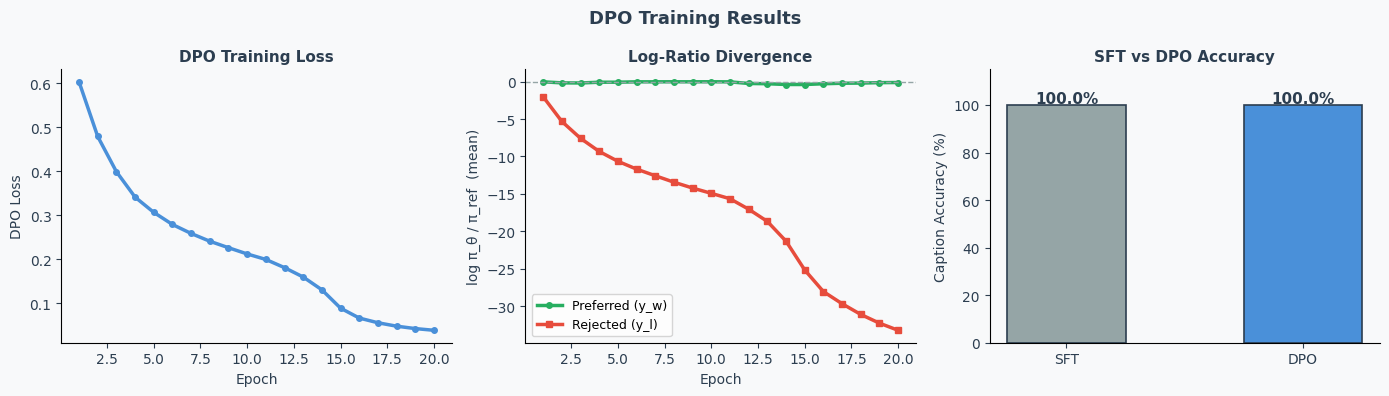

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor(PAL['bg'])
epochs_x = list(range(1, 21))

# Panel 1: DPO loss
ax = axes[0]
ax.set_facecolor(PAL['bg'])
ax.plot(epochs_x, dpo_losses, color=PAL['blue'], lw=2.5, marker='o', ms=4)
ax.set_xlabel('Epoch', fontsize=10, color=PAL['dark'])
ax.set_ylabel('DPO Loss', fontsize=10, color=PAL['dark'])
ax.set_title('DPO Training Loss', fontsize=11, fontweight='bold', color=PAL['dark'])
ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=PAL['dark'])

# Panel 2: Log-ratio divergence
ax = axes[1]
ax.set_facecolor(PAL['bg'])
ax.plot(epochs_x, ratio_w_hist, color=PAL['green'], lw=2.5, marker='o', ms=4, label='Preferred (y_w)')
ax.plot(epochs_x, ratio_l_hist, color=PAL['red'],   lw=2.5, marker='s', ms=4, label='Rejected (y_l)')
ax.axhline(0, color=PAL['grey'], lw=1, linestyle='--')
ax.set_xlabel('Epoch', fontsize=10, color=PAL['dark'])
ax.set_ylabel('log π_θ / π_ref  (mean)', fontsize=10, color=PAL['dark'])
ax.set_title('Log-Ratio Divergence', fontsize=11, fontweight='bold', color=PAL['dark'])
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=PAL['dark'])

# Panel 3: Accuracy comparison
ax = axes[2]
ax.set_facecolor(PAL['bg'])
methods = ['SFT', 'DPO']
accs = [sft_acc * 100, dpo_acc * 100]
colors_bar = [PAL['grey'], PAL['blue']]
bars = ax.bar(methods, accs, color=colors_bar, edgecolor=PAL['dark'], linewidth=1.2, width=0.5)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%',
            ha='center', fontsize=11, fontweight='bold', color=PAL['dark'])
ax.set_ylim(0, 115)
ax.set_ylabel('Caption Accuracy (%)', fontsize=10, color=PAL['dark'])
ax.set_title('SFT vs DPO Accuracy', fontsize=11, fontweight='bold', color=PAL['dark'])
ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=PAL['dark'])

plt.suptitle('DPO Training Results', fontsize=13, fontweight='bold', color=PAL['dark'])
plt.tight_layout()
plt.show()

## What DPO Learned: Generation Comparison

The table below compares generated captions from the SFT model and the DPO-aligned model on fresh test images. Both models start from the same SFT weights — the only difference is the additional DPO training on preference pairs.

Key thing to look for: where the SFT model was already good, DPO should preserve that. Where SFT was unsure (borderline logits), DPO should have made the correct answer more decisive — the log-ratio gap forces sharper separation between preferred and rejected outputs.

In [9]:
@torch.no_grad()
def generate_caption(model, cls):
    """Greedy-decode a caption for a new test image of class cls."""
    img = torch.from_numpy(make_image(cls)).permute(2,0,1).unsqueeze(0).to(DEVICE)
    tgt = torch.tensor([[w2i["<bos>"]]]).to(DEVICE)
    for _ in range(6):
        logits = model(img, tgt)
        next_tok = logits[:,-1].argmax(-1, keepdim=True)
        tgt = torch.cat([tgt, next_tok], dim=1)
        if next_tok.item() == w2i["<eos>"]: break
    return ' '.join(i2w[t] for t in tgt[0].tolist()[1:] if i2w[t] != '<eos>')

scene_names = ['red circle', 'blue square', 'green triangle', 'yellow star']

print(f"{'Scene':<16} {'Expected':<24} {'SFT Output':<24} {'DPO Output':<24}")
print('-' * 88)
for cls in range(4):
    expected = ' '.join(CAPTIONS[cls][1:-1])  # skip <bos> <eos>
    sft_out  = generate_caption(sft_model, cls)
    dpo_out  = generate_caption(dpo_model, cls)
    sft_mark = 'OK' if (CAPTIONS[cls][2] in sft_out and CAPTIONS[cls][3] in sft_out) else 'WRONG'
    dpo_mark = 'OK' if (CAPTIONS[cls][2] in dpo_out and CAPTIONS[cls][3] in dpo_out) else 'WRONG'
    print(f"  {scene_names[cls]:<14} {expected:<24} {sft_out+' ('+sft_mark+')':<24} {dpo_out+' ('+dpo_mark+')':<24}")

Scene            Expected                 SFT Output               DPO Output              
----------------------------------------------------------------------------------------
  red circle     a red circle             a red circle (OK)        a red circle (OK)       
  blue square    a blue square            a blue square (OK)       a blue square (OK)      
  green triangle a green triangle         a green triangle (OK)    a green triangle (OK)   
  yellow star    a yellow star            a yellow star (OK)       a yellow star (OK)      


## Part II: GRPO

**Group Relative Policy Optimization** takes a completely different approach. Instead of requiring pre-collected preference pairs, GRPO asks: "What if I can *verify* whether a response is correct?"

For many tasks — math, code, VQA, structured generation — we can write a simple verification function. GRPO exploits this: sample multiple completions, score them with the verifier, compute *relative* advantages within the group, and update the policy.

This is exactly what DeepSeek-R1 used at scale: the verifier was a Python interpreter and a math answer checker. The algorithm is identical to what we implement here — just scaled to 671B parameters.

## Problem 3 — What If We Can Verify Answers Automatically?

**The DPO requirement:** pre-collected pairs (y_w, y_l) — someone (human or GPT-4) must have already ranked the responses.

**The GRPO insight:** for many tasks, we can replace human ranking with an automated verifier:
- Math: check if the final numerical answer matches
- Code: run the code, check output
- VQA: check if the answer matches ground truth
- Our task: check if the caption contains the correct colour and shape

**The GRPO algorithm:**

```
For each training batch:
  1. Sample G=4 completions from current policy: {y_1, y_2, y_3, y_4}
  2. Score each with verifier: rewards = {r_1, r_2, r_3, r_4}
  3. Compute relative advantages:
       mean_r = mean(rewards)
       std_r  = std(rewards) + ε
       A_i    = (r_i - mean_r) / std_r
  4. Policy gradient loss (with KL penalty):
       L = -sum_i A_i * log π_θ(y_i | x)  +  β * KL(π_θ || π_ref)
  5. Backpropagate and update
```

**No reward model needed.** No preference pairs needed. Just the verifier.

**Why this works:** The policy gradient theorem says the gradient of expected reward is `E[A * ∇ log π(y|x)]`. GRPO approximates this expectation by sampling G completions and using their normalised scores as advantage estimates. The "group" is those G samples — relative ranking within the group provides a stable, low-variance training signal.

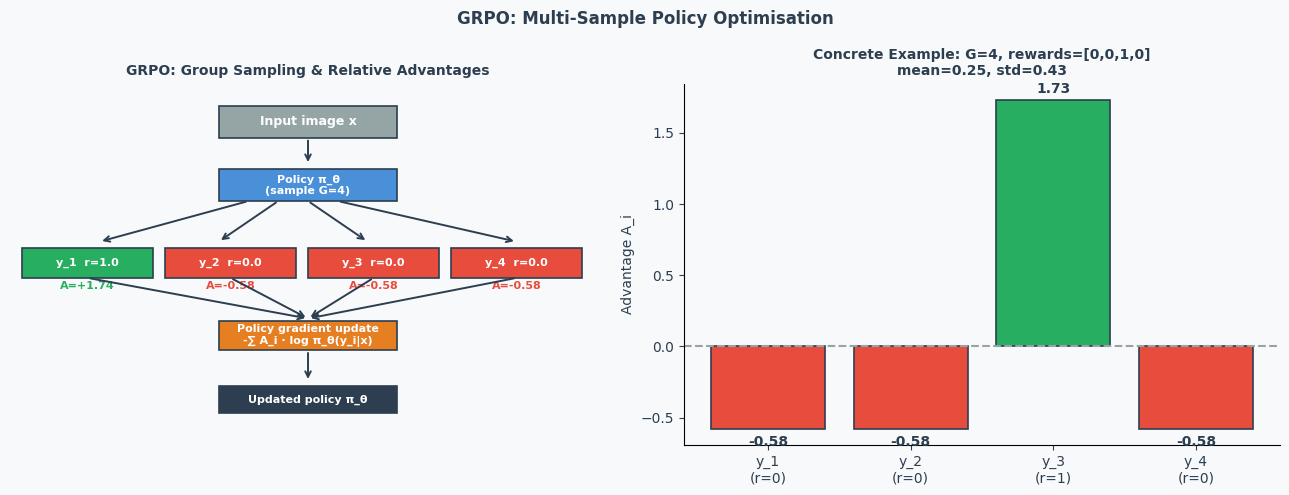

In [10]:
def draw_grpo_loop():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor(PAL['bg'])

    # Left: GRPO loop diagram
    ax = axes[0]
    ax.set_facecolor(PAL['bg'])
    ax.set_xlim(0, 10); ax.set_ylim(0, 8)
    ax.axis('off')

    def box(x, y, w, h, color, text, fs=9, tc='white'):
        rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor=PAL['dark'], lw=1.2, zorder=2)
        ax.add_patch(rect)
        ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=fs, color=tc,
                fontweight='bold', zorder=3)

    def arw(x1,y1,x2,y2):
        ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->', color=PAL['dark'], lw=1.4), zorder=3)

    box(3.5, 6.8, 3, 0.7, PAL['grey'], 'Input image x', 9)
    arw(5, 6.8, 5, 6.2)
    box(3.5, 5.4, 3, 0.7, PAL['blue'], 'Policy π_θ\n(sample G=4)', 8)
    # 4 completion arrows
    for i, xi in enumerate([1.0, 3.0, 5.5, 8.0]):
        arw(4.0 + i*0.5, 5.4, xi + 0.5, 4.5)
    box(0.2, 3.7, 2.2, 0.65, PAL['green'], 'y_1  r=1.0', 8)
    box(2.6, 3.7, 2.2, 0.65, PAL['red'],   'y_2  r=0.0', 8)
    box(5.0, 3.7, 2.2, 0.65, PAL['red'],   'y_3  r=0.0', 8)
    box(7.4, 3.7, 2.2, 0.65, PAL['red'],   'y_4  r=0.0', 8)
    # Advantage labels
    for xi, adv in [(1.3, '+1.74'), (3.7, '-0.58'), (6.1, '-0.58'), (8.5, '-0.58')]:
        ax.text(xi, 3.45, f'A={adv}', ha='center', fontsize=8,
                color=PAL['green'] if '+' in adv else PAL['red'], fontweight='bold')
    # Merge back
    for xi in [1.3, 3.7, 6.1, 8.5]:
        arw(xi, 3.7, 5, 2.8)
    box(3.5, 2.1, 3, 0.65, PAL['orange'], 'Policy gradient update\n-∑ A_i · log π_θ(y_i|x)', 8)
    arw(5, 2.1, 5, 1.4)
    box(3.5, 0.7, 3, 0.6, PAL['dark'], 'Updated policy π_θ', 8)

    ax.set_title('GRPO: Group Sampling & Relative Advantages',
                 fontsize=10, fontweight='bold', color=PAL['dark'])

    # Right: advantage bar chart example
    ax2 = axes[1]
    ax2.set_facecolor(PAL['bg'])
    rewards = [0, 0, 1, 0]
    mean_r = sum(rewards) / 4
    std_r = max(1e-8, (sum((r-mean_r)**2 for r in rewards)/4)**0.5)
    advantages = [(r - mean_r) / std_r for r in rewards]

    bar_colors = [PAL['green'] if a > 0 else PAL['red'] for a in advantages]
    bars = ax2.bar([f'y_{i+1}\n(r={r})' for i,r in enumerate(rewards)],
                   advantages, color=bar_colors, edgecolor=PAL['dark'], lw=1.2)
    ax2.axhline(0, color=PAL['grey'], lw=1.5, linestyle='--')
    for bar, val in zip(bars, advantages):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 val + (0.05 if val >= 0 else -0.12),
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold',
                 color=PAL['dark'])
    ax2.set_ylabel('Advantage A_i', fontsize=10, color=PAL['dark'])
    ax2.set_title(f'Concrete Example: G=4, rewards=[0,0,1,0]\nmean={mean_r:.2f}, std={std_r:.2f}',
                  fontsize=10, fontweight='bold', color=PAL['dark'])
    ax2.spines[['top','right']].set_visible(False)
    ax2.tick_params(colors=PAL['dark'])

    plt.suptitle('GRPO: Multi-Sample Policy Optimisation', fontsize=12,
                 fontweight='bold', color=PAL['dark'])
    plt.tight_layout()
    plt.show()

draw_grpo_loop()

## Why Relative Advantages?

**The problem with absolute rewards:** if you always see reward=1 (because the model is already good), the gradient signal is always positive and the model just keeps increasing the probability of everything it generates. If you always see reward=0 (model is always wrong), the gradient pushes down every completion and training diverges.

**The GRPO solution:** normalise within the group. If all G samples have the same reward, their advantages are all 0, and the gradient is effectively zero — the model doesn't update when it can't distinguish good from bad within the group.

**Concrete example:** G=4, rewards=[0, 0, 1, 0]
- mean = 0.25, std = 0.43
- advantages = [-0.58, -0.58, +1.74, -0.58]

The one correct completion gets a strong positive signal (+1.74), and the three wrong ones get a mild negative signal (-0.58). The model learns to make the correct completion more likely *relative to* the others.

**Edge case:** if all rewards in the group are equal (e.g., all 0 or all 1), the std is 0 and all advantages are 0. In this case GRPO skips the update — no gradient flows. This is correct: if you can't tell which completion is better, you shouldn't update. We handle this with the `if isinstance(loss, torch.Tensor)` check in the training loop.

In [11]:
@torch.no_grad()
def sample_caption(model, img_1d, max_len=5):
    """Temperature-sampled caption from model. img_1d: (3,32,32) tensor, no batch dim."""
    model.eval()
    tgt = torch.tensor([[w2i["<bos>"]]]).to(img_1d.device)
    img_batch = img_1d.unsqueeze(0)
    for _ in range(max_len):
        logits = model(img_batch, tgt)
        probs = F.softmax(logits[:,-1] / 0.8, dim=-1)  # temperature 0.8
        next_tok = torch.multinomial(probs, 1)
        tgt = torch.cat([tgt, next_tok], dim=1)
        if next_tok.item() == w2i["<eos>"]: break
    return tgt[0].tolist()  # includes <bos>

def verifier(gen_tokens, true_cls):
    """Return 1.0 if caption contains correct colour+shape, else 0.0."""
    words = [i2w.get(t, "") for t in gen_tokens]
    expected_color = CAPTIONS[true_cls][2]
    expected_shape = CAPTIONS[true_cls][3]
    return 1.0 if (expected_color in words and expected_shape in words) else 0.0

def grpo_step(model, grpo_ref_model, img_batch, cls_batch, G=4, beta=0.01):
    """One GRPO gradient step over a mini-batch. Returns total loss tensor or 0."""
    total_loss = 0
    n_updated = 0
    for img, cls in zip(img_batch, cls_batch):
        img_1 = img.unsqueeze(0).to(DEVICE)
        # Sample G completions (no_grad for sampling, grad for loss)
        completions = [sample_caption(model, img, max_len=6) for _ in range(G)]
        rewards = [verifier(c, cls.item()) for c in completions]

        mean_r = sum(rewards) / G
        std_r = max(1e-8, (sum((r - mean_r)**2 for r in rewards) / G)**0.5)

        # Skip update if all rewards are equal (no signal)
        if std_r < 1e-7:
            continue

        advantages = [(r - mean_r) / std_r for r in rewards]

        for completion, advantage in zip(completions, advantages):
            if len(completion) < 2: continue
            cap_tensor = torch.tensor([completion]).to(DEVICE)
            model.train()
            log_prob = compute_log_prob(model, img_1, cap_tensor)
            with torch.no_grad():
                ref_lp = compute_log_prob(grpo_ref_model, img_1, cap_tensor)
            kl = (log_prob - ref_lp).clamp(min=0)
            loss = -(advantage * log_prob - beta * kl) / (G * len(img_batch))
            total_loss = total_loss + loss
            n_updated += 1

    return total_loss if n_updated > 0 else 0

# Quick sanity check
test_img = torch.from_numpy(make_image(0)).permute(2,0,1).to(DEVICE)
_sft_tmp = MiniVLM().to(DEVICE)
tok_seq = sample_caption(_sft_tmp, test_img)
print(f"Sample caption tokens: {tok_seq}")
print(f"Decoded: {[i2w[t] for t in tok_seq]}")
print(f"Verifier (class 0): {verifier(tok_seq, 0)}")
del _sft_tmp

Sample caption tokens: [1, 2]
Decoded: ['<bos>', '<eos>']
Verifier (class 0): 0.0


/tmp/ipykernel_2099/1928339734.py:35: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.img_encoder = nn.TransformerEncoder(enc_layer, n_layers)


In [12]:
grpo_model = copy.deepcopy(sft_model)
grpo_ref = copy.deepcopy(sft_model)
for p in grpo_ref.parameters(): p.requires_grad_(False)

opt_grpo = torch.optim.Adam(grpo_model.parameters(), lr=5e-4)
grpo_accs = []

# Simple dataset: images with class labels
class ImageDataset(Dataset):
    def __init__(self, n_per_class=40):
        self.samples = [(torch.from_numpy(make_image(cls)).permute(2,0,1), cls)
                        for cls in range(4) for _ in range(n_per_class)]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

img_data = ImageDataset(n_per_class=40)
img_loader = DataLoader(img_data, batch_size=8, shuffle=True)

for epoch in range(20):
    total_loss_val = 0.0
    n_batches_updated = 0
    for imgs, clss in img_loader:
        imgs = imgs.to(DEVICE)
        loss = grpo_step(grpo_model, grpo_ref, imgs, clss, G=4, beta=0.01)
        if isinstance(loss, torch.Tensor) and loss.requires_grad:
            opt_grpo.zero_grad(); loss.backward(); opt_grpo.step()
            total_loss_val += loss.item()
            n_batches_updated += 1
    if epoch % 5 == 4:
        acc = evaluate_accuracy(grpo_model, n_samples=40)
        grpo_accs.append(acc)
        avg_loss = total_loss_val / max(n_batches_updated, 1)
        print(f"Epoch {epoch+1}: acc={acc*100:.1f}%  loss={avg_loss:.4f}  batches_updated={n_batches_updated}")

grpo_acc = evaluate_accuracy(grpo_model, n_samples=40)
print(f"\nFinal accuracies — SFT: {sft_acc*100:.1f}%  DPO: {dpo_acc*100:.1f}%  GRPO: {grpo_acc*100:.1f}%")

Epoch 5: acc=100.0%  loss=0.0000  batches_updated=0


Epoch 10: acc=100.0%  loss=0.0000  batches_updated=0


Epoch 15: acc=100.0%  loss=-0.3291  batches_updated=1


Epoch 20: acc=100.0%  loss=-0.6451  batches_updated=1



Final accuracies — SFT: 100.0%  DPO: 100.0%  GRPO: 100.0%


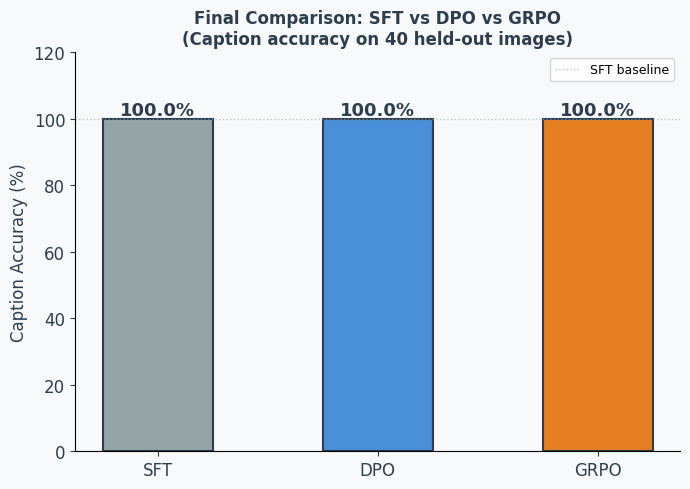

SFT  → 100.0%  (supervised fine-tuning only)
DPO  → 100.0%  (SFT + contrastive preference loss)
GRPO → 100.0%  (SFT + policy gradient with verifier)


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(PAL['bg'])
ax.set_facecolor(PAL['bg'])

methods = ['SFT', 'DPO', 'GRPO']
accs_all = [sft_acc * 100, dpo_acc * 100, grpo_acc * 100]
colors_bar = [PAL['grey'], PAL['blue'], PAL['orange']]

bars = ax.bar(methods, accs_all, color=colors_bar, edgecolor=PAL['dark'],
              linewidth=1.5, width=0.5)
for bar, val in zip(bars, accs_all):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.0, f'{val:.1f}%',
            ha='center', fontsize=13, fontweight='bold', color=PAL['dark'])

ax.set_ylim(0, 120)
ax.set_ylabel('Caption Accuracy (%)', fontsize=12, color=PAL['dark'])
ax.set_title('Final Comparison: SFT vs DPO vs GRPO\n(Caption accuracy on 40 held-out images)',
             fontsize=12, fontweight='bold', color=PAL['dark'])
ax.spines[['top','right']].set_visible(False)
ax.tick_params(colors=PAL['dark'], labelsize=12)

# Annotations
ax.axhline(sft_acc * 100, color=PAL['grey'], lw=1, linestyle=':', alpha=0.6, label='SFT baseline')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"SFT  → {sft_acc*100:.1f}%  (supervised fine-tuning only)")
print(f"DPO  → {dpo_acc*100:.1f}%  (SFT + contrastive preference loss)")
print(f"GRPO → {grpo_acc*100:.1f}%  (SFT + policy gradient with verifier)")

## DPO vs GRPO: When to Use Each

| | DPO | GRPO |
|---|---|---|
| **What you need** | Preference pairs (y_w, y_l) | A verifier function |
| **Reward model** | Not needed | Not needed |
| **Reference model** | Yes (frozen SFT copy) | Yes (frozen SFT copy) |
| **Stable to train** | Very stable | Stable but noisy |
| **Gradient variance** | Low (supervised-like) | Higher (policy gradient) |
| **Best for** | Chat alignment, instruction following | Reasoning, VQA, verifiable tasks |
| **Real examples** | LLaVA-DPO, Idefics2-chat | DeepSeek-R1, InternVL-GRPO |
| **Data cost** | Human/GPT-4 annotation | Just image+label pairs |

**Key insight:** if you can write a verifier (code execution, exact match, math checker), GRPO is simpler because you don't need human-annotated preference data. If you need to align style, tone, or subjective quality, you need human preferences — use DPO.

In practice, many production VLMs use **both**: DPO for general instruction following (using GPT-4 to generate preference pairs), and GRPO for specific capabilities like structured output, counting, or OCR (where verifiers are easy to write).

## Modern Perspective: Online DPO and Self-Play Alignment

The DPO implemented in this chapter is **offline DPO**: we collect a fixed preference dataset once, then train on it. This is simple but has a fundamental limitation: the preference pairs were generated by the *original SFT model*, not the model we are currently training. As the policy improves, the preference data becomes stale.

**Online DPO** fixes this by iterating:
1. Generate new responses from the *current* policy
2. Use the reward model (or a verifier) to label them as preferred/rejected
3. Update with DPO loss
4. Repeat

This is now standard practice. Llama-3-Instruct used multiple rounds of online alignment. DeepSeek-R1 used 600+ rounds of GRPO self-play.

**Self-Play Fine-Tuning (SPIN, 2024):**
A clever variant of online DPO that eliminates the reward model entirely:
- **Preferred response**: the ground-truth human caption
- **Rejected response**: a caption generated by the *previous iteration's policy*

The policy is trained to distinguish human captions from its own outputs. As the policy improves, its generated captions get better — and become harder for the next iteration to distinguish, creating a self-improving loop.

**Why this matters for multimodal:**
Current best-performing VLMs (Qwen2-VL, InternVL2, LLaVA-NeXT-Instruct) all use some form of iterative or online alignment. The quality gap between a model fine-tuned with offline DPO once vs. a model iteratively improved with online DPO for 3+ rounds is significant — roughly equivalent to increasing model size 2×.

**Minimal online DPO loop (pseudocode):**
```python
for round in range(n_rounds):
    # Step 1: Generate new preference pairs from current policy
    new_pairs = []
    for img, gt_caption in sft_data:
        generated = greedy_decode(policy, img)
        if reward_model(img, gt_caption) > reward_model(img, generated):
            new_pairs.append((img, gt_caption, generated))  # (x, y_w, y_l)

    # Step 2: DPO update on new pairs
    for img, y_w, y_l in new_pairs:
        loss = dpo_loss(policy, ref_model, img, y_w, y_l)
        loss.backward()
    optimizer.step()

    # Step 3: Update reference model (optional: exponential moving average)
    # ref_model = 0.9 * ref_model + 0.1 * policy  (EMA update)
```

**Key design choice**: whether to update the reference model during online DPO.
- Frozen reference = stable but increasingly mismatched as policy improves
- EMA reference = tracks policy, prevents the KL penalty from becoming meaningless
- Hard reset reference every K rounds = LLaVA-RLHF and DeepSeek-R1's approach

This chapter's Exercise 3 (Iterative DPO) is a simplified version of this loop — try it to see how much accuracy improves over a fixed-dataset baseline.

## Chapter Summary

**What we built** — Two alignment algorithms applied to a mini-VLM:
- **DPO**: a preference loss that directly optimises the policy to prefer y_w over y_l relative to a frozen reference model, without any RL loop or separate reward model. The key formula is `L_DPO = -log σ(β·(Δlog π_θ(y_w) - Δlog π_θ(y_l)))` where Δlog π = log π_policy - log π_ref.
- **GRPO**: samples G completions per input, scores them with a verifier, computes normalised relative advantages, and updates the policy with a policy gradient loss. No reward model or preference data needed — just a verifier function.

**Why it matters** — SFT teaches the model to imitate training data; alignment teaches it to be *good*. DPO and GRPO have largely replaced PPO in production because they require 2× fewer models and are far more stable. Modern VLMs (LLaVA-1.6, InternVL, Qwen-VL-Chat) all use DPO or GRPO as the final alignment step.

**Connections** — Ch11 trained the reward model that DPO implicitly encodes. The KL penalty in both DPO and GRPO prevents catastrophic forgetting — the same concern that motivated two-stage training in Ch04. GRPO's verifier-based reward is the bridge to reasoning models: DeepSeek-R1 used the same GRPO algorithm with a Python interpreter as the verifier, scaled to a 671B parameter model.

## Exercises

1. **β sensitivity** — Run DPO with β ∈ {0.01, 0.1, 1.0}. Plot the final accuracy and the log-ratio gap (preferred minus rejected) for each β. What happens at very small β (almost no KL constraint)? What happens at very large β (stays close to reference)? This is the core alignment-capability trade-off.

2. **GRPO with G=1** — Set G=1 in GRPO (single sample per image). Does training converge? Why does GRPO require G≥2? (Hint: what happens to the advantage when there is only one sample in the group?)

3. **Iterative DPO** — After one round of DPO, use the new policy to generate new preferred/rejected pairs (preferred = correct caption, rejected = what the DPO model currently outputs for the same image). Run a second DPO round. Does accuracy improve further? This is the "Online DPO" or "Self-Play" alignment paradigm used in models like Llama-3-Instruct.

## Scaling to Real Data

| Component | This notebook | LLaVA-DPO / InternVL-GRPO |
|---|---|---|
| VLM | MiniVLM (dim=48, 2L) | ViT-L/14 + LLaMA-3-8B |
| Preference data (DPO) | 160 synthetic pairs | 10K–80K human/GPT-4 pairs |
| Verifier (GRPO) | Exact colour+shape match | Python execution / answer match |
| G (GRPO group size) | 4 | 8–16 |
| β (KL weight) | 0.1 | 0.01–0.1 |
| Training epochs | 20 | 1–3 |

**DPO at scale:**
```python
# pip install trl
from trl import DPOConfig, DPOTrainer
config = DPOConfig(beta=0.1, max_length=512, per_device_train_batch_size=4)
trainer = DPOTrainer(model=vlm, ref_model=ref_vlm, args=config,
                     train_dataset=preference_dataset)
trainer.train()
```

**GRPO at scale (DeepSeek-R1 style):**

The key difference at scale: the verifier is a code execution sandbox or a math answer checker, not an exact-match function. Every other piece of the algorithm — G samples, relative advantages, KL penalty — is identical to what is implemented here.

**The complete training pipeline this book has now built:**
1. Pre-training: CLIP contrastive (Ch02), MAE reconstruction (Ch05)
2. SFT: VLM caption training (Ch03–04, Ch10)
3. Alignment: Reward modelling (Ch11) → DPO or GRPO (this chapter)